# 🔍 Interactive Simulator: Lenses and The Sliding Box

### Welcome, Opticians!
In our last simulator, we saw that a pinhole camera makes things sharp but very dark. Today, we are upgrading to **Glass**.

A convex lens (like a magnifying glass) takes millions of light rays and bends them all to a single, bright point. But there is a catch: to keep the picture sharp, the distance between the lens and the screen has to change depending on how far away your subject is!

**Teacher Instructions:** Run the code blocks below to visualize focal lengths and the math behind the Sliding Box Camera.

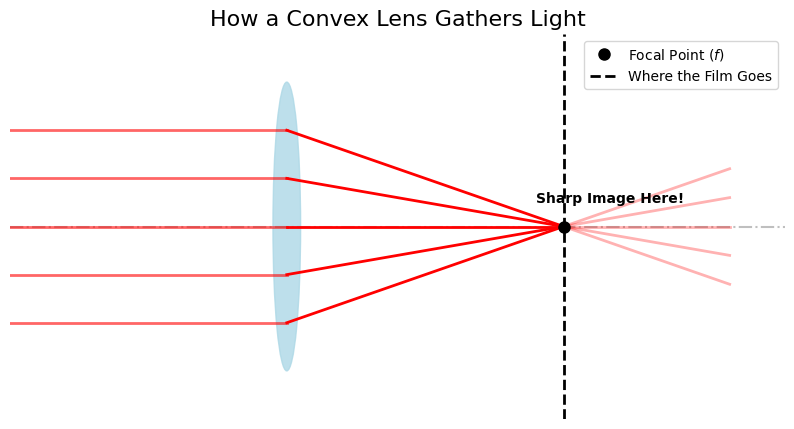

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

def simulate_lens_focus():
    """Simulates parallel light rays passing through a convex lens."""
    fig, ax = plt.subplots(figsize=(10, 5))
    
    focal_length = 5.0  # Let's say our magnifying glass has a 5cm focal length
    
    # Draw the optical axis (the invisible center line)
    ax.axhline(0, color='gray', linestyle='-.', alpha=0.5)
    
    # Draw the Lens (as a thin blue ellipse)
    lens = patches.Ellipse((0, 0), width=0.5, height=6, color='lightblue', alpha=0.8)
    ax.add_patch(lens)
    
    # Draw Incoming Parallel Rays (from a subject very far away)
    y_positions = [-2, -1, 0, 1, 2]
    for y in y_positions:
        # Ray coming in from the left
        ax.plot([-5, 0], [y, y], 'r-', lw=2, alpha=0.6)
        
        # Ray bending through the lens to hit the focal point (focal_length, 0)
        ax.plot([0, focal_length], [y, 0], 'r-', lw=2)
        
        # Ray continuing past the focal point (getting blurry again!)
        ax.plot([focal_length, focal_length + 3], [0, -y*(3/focal_length)], 'r-', lw=2, alpha=0.3)

    # Mark the Focal Point
    ax.plot(focal_length, 0, 'ko', markersize=8, label="Focal Point ($f$)")
    ax.text(focal_length - 0.5, 0.5, "Sharp Image Here!", fontweight='bold')
    
    # Mark the Sensor/Film Plane
    ax.axvline(focal_length, color='black', linestyle='--', lw=2, label="Where the Film Goes")

    ax.set_title("How a Convex Lens Gathers Light", fontsize=16)
    ax.set_xlim(-5, 9)
    ax.set_ylim(-4, 4)
    ax.set_xlabel("Distance (cm)")
    ax.axis('off')
    ax.legend(loc="upper right")
    plt.show()

# Run the Lens Simulator!
simulate_lens_focus()

In [2]:
def calculate_sharpness(hole_diameter_mm, distance_to_wall_meters):
    """
    Calculates the 'f-stop' of our Room Camera to see how sharp it is.
    """
    focal_length_mm = distance_to_wall_meters * 1000
    
    # f-stop = Focal Length / Diameter
    f_stop = focal_length_mm / hole_diameter_mm
    
    print(f"--- Room Camera Stats ---")
    print(f"Distance to Wall: {distance_to_wall_meters} meters")
    print(f"Hole Diameter:    {hole_diameter_mm} mm")
    print(f"Aperture:         f/{f_stop:.0f}")
    
    if f_stop < 100:
        return "Result: BLURRY. The hole is too big!"
    elif f_stop > 500:
        return "Result: TOO DARK. The hole is too small!"
    else:
        return "Result: PERFECT. Sharp image."

# Try changing these numbers!
print(calculate_sharpness(hole_diameter_mm=5, distance_to_wall_meters=3))

--- Room Camera Stats ---
Distance to Wall: 3 meters
Hole Diameter:    5 mm
Aperture:         f/600
Result: TOO DARK. The hole is too small!


### 📐 The Thin Lens Equation
The simulation above shows what happens when looking at something very far away (like the Sun or mountains). The light rays come in perfectly straight, and the image forms exactly at the focal length ($f$).

But what if your friend stands right in front of the camera? The light rays are entering the lens at steep angles! 

We use the **Thin Lens Equation** to find out where the sharp picture will form:
$$\frac{1}{f} = \frac{1}{d_o} + \frac{1}{d_i}$$

* **$f$** = Focal Length of the lens (This is built into the glass. It cannot change).
* **$d_o$** = Distance to Object (How far away your friend is).
* **$d_i$** = Distance to Image (How far you need to slide the back of the camera to find the focus).

Let's graph this math to see how much we need to move our sliding box!

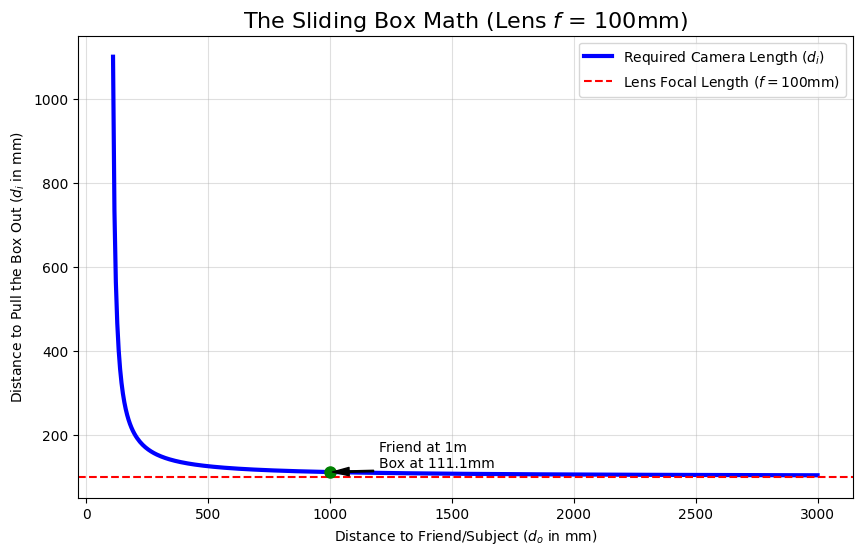

In [3]:
def sliding_box_calculator(focal_length_mm=100):
    """Graphs the required image distance (di) based on object distance (do)."""
    # Create an array of object distances from 150mm to 3000mm (3 meters)
    do = np.linspace(focal_length_mm * 1.1, 3000, 500) 
    
    # Rearrange the Thin Lens Equation to solve for d_i:
    # 1/di = 1/f - 1/do  --->  di = (f * do) / (do - f)
    di = (focal_length_mm * do) / (do - focal_length_mm)
    
    plt.figure(figsize=(10, 6))
    
    # Plot the curve
    plt.plot(do, di, 'b-', lw=3, label="Required Camera Length ($d_i$)")
    
    # Draw a line representing the focal length limit
    plt.axhline(focal_length_mm, color='r', linestyle='--', 
                label=f"Lens Focal Length ($f = {focal_length_mm}$mm)")
    
    # Formatting the graph
    plt.title(f"The Sliding Box Math (Lens $f$ = {focal_length_mm}mm)", fontsize=16)
    plt.xlabel("Distance to Friend/Subject ($d_o$ in mm)")
    plt.ylabel("Distance to Pull the Box Out ($d_i$ in mm)")
    plt.grid(True, alpha=0.4)
    plt.legend()
    
    # Highlight a specific example
    example_do = 1000 # Friend is 1 meter away
    example_di = (focal_length_mm * example_do) / (example_do - focal_length_mm)
    plt.plot(example_do, example_di, 'go', markersize=8)
    plt.annotate(f"Friend at 1m \nBox at {example_di:.1f}mm", 
                 xy=(example_do, example_di), xytext=(example_do + 200, example_di + 10),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

    plt.show()

# Run the Sliding Box Calculator!
sliding_box_calculator(focal_length_mm=100) # Assuming a 100mm magnifying glass

### 🛠️ What the Graph Tells Us
Look at the blue line. It represents how long your physical camera box needs to be.

1. **Infinity Focus:** When your subject is very far away (the far right side of the graph), the blue line almost touches the red dotted line. Your box only needs to be about 100mm long.
2. **Close Focus:** As your subject walks closer to the camera (moving left on the graph), the blue line shoots straight up! If your friend gets too close, you have to slide the box way out to keep them sharp.

This is why camera lenses physically extend and rotate outward when you try to focus on something right in front of your face!